# PMMH Plotting

This notebook contains code for plotting the results of the PMMH algorithm. The first part deals with plotting the results of synthetic data, while the second part focuses on plotting the results of real data.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from pathlib import Path

import os
import sys
import ast

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)


d:\School\Fakulteta\2. stopnja\2. letnik\Master


In [2]:
def generate_names(n_params):
    """
    Generate dynamically parameter names based on the number of parameters. 
    First 1 is "mu1", next K-1 are "delta_i", next one is "phi", next one is "sigma" and then K*K flatten parameters P_ij.
    In total there is 1 + (K-1) + 1 + 1 + K*K = K*K + K + 2 parameters.
    """
    K = int(-1+np.sqrt(n_params+1))

    names = []
    names.append("mu1")
    for i in range(K-1):
        names.append(f"delta_{i}")
    names.append("phi")
    names.append("sigma")
    for i in range(K):
        for j in range(K):
            names.append(f"P_{i}_{j}")

    return names

## Synthetic Data

We plot resutls for multiple datasets, each with different regime settings. We have 6 synthetic datasets, each with 2 regimes. First three datasets have similar parameters as follows:
- $\mu_1 = -5.0$
- $\mu_2 = -2.0$
- $\sigma = 0.1$
- $P = \begin{bmatrix} 0.99 & 0.01 \\ 0.015 & 0.985 \end{bmatrix}$

with different $\phi$ values:
- Dataset 1: $\phi = 0.9$
- Dataset 2: $\phi = 0.7$
- Dataset 3: $\phi = 0.5$

The next three datasets have again similar parameters as follows:
- $\mu_1 = -1.0$
- $\mu_2 = 1.0$
- $\sigma = 0.1$
- $P = \begin{bmatrix} 0.99 & 0.01 \\ 0.05 & 0.95 \end{bmatrix}$

with different $\phi$ values:
- Dataset 4: $\phi = 0.9$
- Dataset 5: $\phi = 0.7$
- Dataset 6: $\phi = 0.5$




In [51]:
# Dataset name setting. Can use "dataset_1", "dataset_2", "dataset_3", "dataset_4", "dataset_5" or "dataset_6"
name = "dataset_6"

In [52]:
experiment_path = os.path.join(parent_dir, "experiments", "mssv_pmmh_bpf_synth")
output_dir = os.path.join(experiment_path, name, "output")
results_dir = os.path.join(experiment_path, name, "results")
data_dir = os.path.join(parent_dir, "data", "synthetic")

# Convert to pathlib.Path objects for easier path manipulation
output_dir = Path(output_dir)
results_dir = Path(results_dir)
data_dir = Path(data_dir)

In [53]:
# Load true data and parameters
from src.models.mssv import MSSVParams

data = pd.read_csv(data_dir / f"{name}.csv")
y = data["y"].values
h_true = data["h_true"].values
s_true = data["s_true"].values.astype(int)

params_df = pd.read_csv(data_dir / f"{name}_params.csv")
P_rows = params_df["P"].apply(ast.literal_eval).tolist()
P = np.array(P_rows)
true_theta = MSSVParams.from_mu(
    mu=params_df["mu"].values,
    phi=params_df["phi"].iloc[0],
    sigma_eta=params_df["sigma_eta"].iloc[0],
    P=P
)
true_theta = true_theta.to_vector()

In [54]:
# Get number of chain files from output_dir
chain_files = list(output_dir.glob("chain_*.h5"))
n_chains = len(chain_files)
print(f"Found {n_chains} chain files.")
print(output_dir)

# Dictionary to store chain data
chains_data = {}

for i in range(n_chains):
    print(f"Processing chain {i+1}/{n_chains}...")
    with h5py.File(output_dir / f"chain_{i}.h5", "r") as h5f:
        acceptance_rate = h5f.attrs["acceptance_rate"]
        initial_theta = h5f.attrs["initial_parameters"]
        thetas = h5f["thetas"][:]
        logmarliks = h5f["logmarliks"][:]
        logalphas = h5f["logalphas"][:]
        trajectories = h5f["trajectories"][:]

        chains_data[i] = {
            "acceptance_rate": acceptance_rate,
            "initial_theta": initial_theta,
            "thetas": thetas,
            "logmarliks": logmarliks,
            "logalphas": logalphas,
            "trajectories": trajectories
        }

n_params = chains_data[0]["thetas"].shape[1]

parameter_names = generate_names(n_params)
print("Parameter names:", parameter_names)

Found 8 chain files.
d:\School\Fakulteta\2. stopnja\2. letnik\Master\experiments\mssv_pmmh_bpf_synth\dataset_6\output
Processing chain 1/8...
Processing chain 2/8...
Processing chain 3/8...
Processing chain 4/8...
Processing chain 5/8...
Processing chain 6/8...
Processing chain 7/8...
Processing chain 8/8...
Parameter names: ['mu1', 'delta_0', 'phi', 'sigma', 'P_0_0', 'P_0_1', 'P_1_0', 'P_1_1']


First we plot traceplots for all parameters $\mu_1, \delta_0, \phi, \sigma$ and $P$. The plots are saved in the `results_dir` directory.

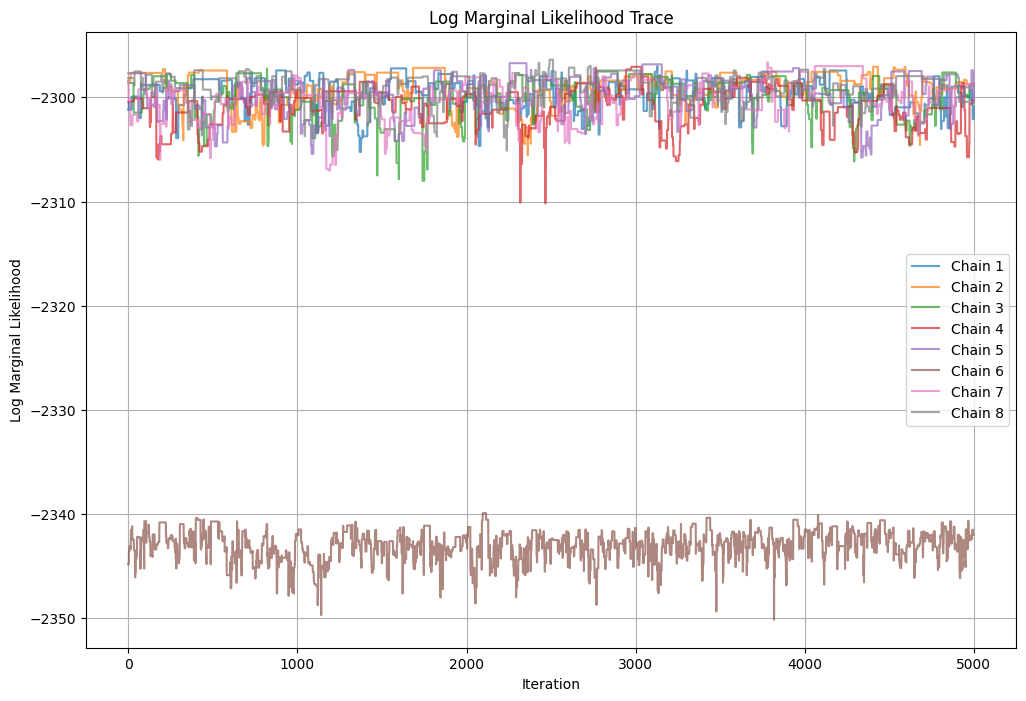

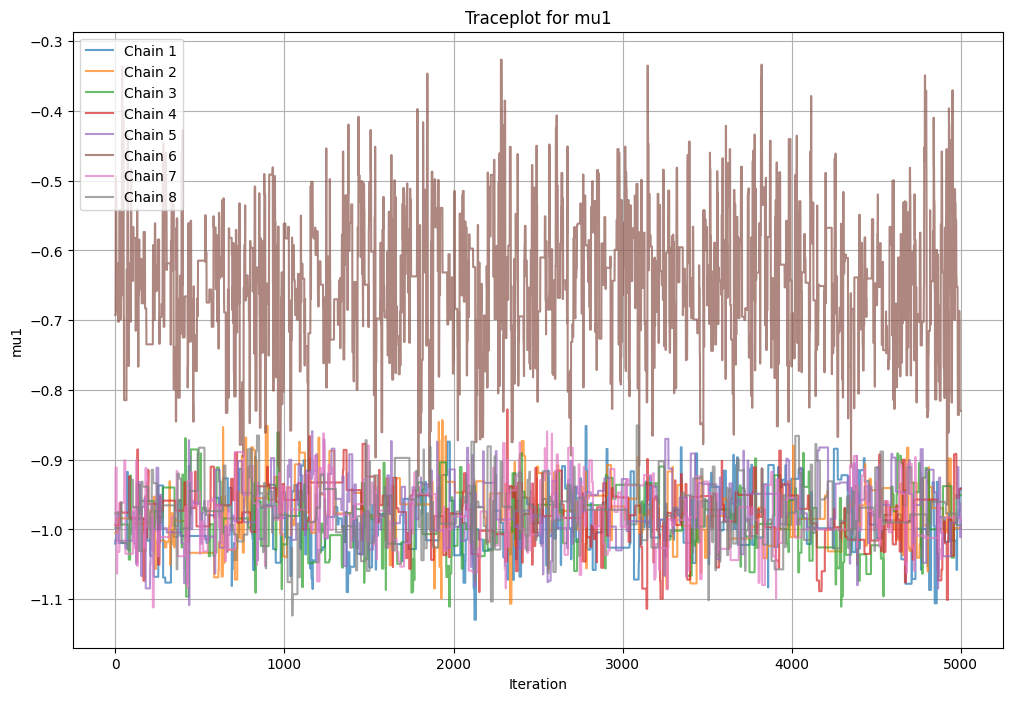

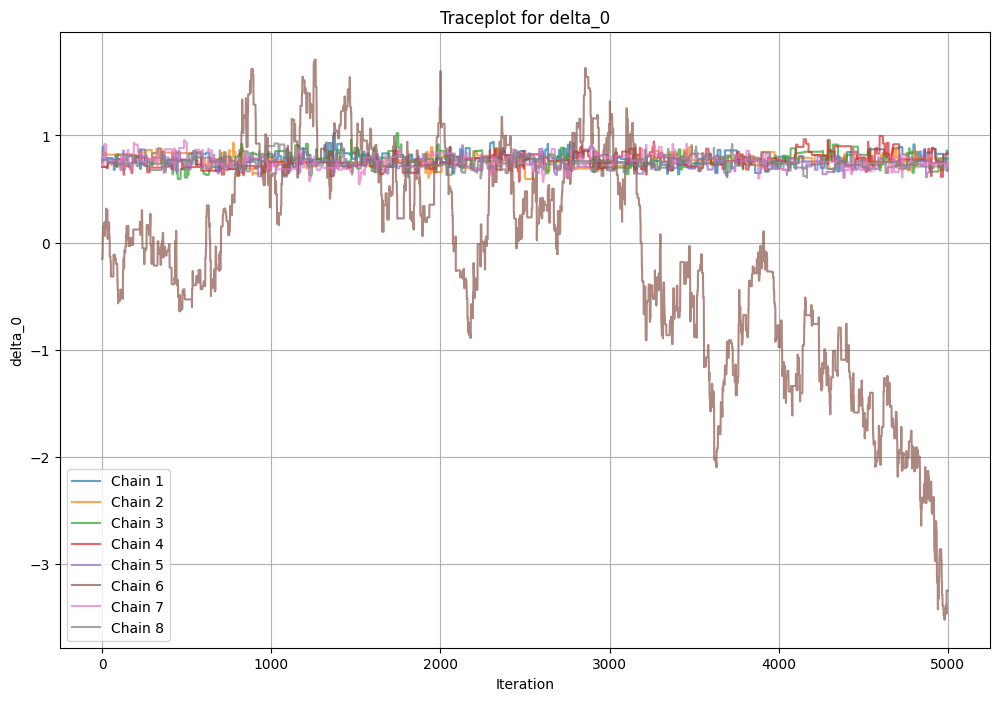

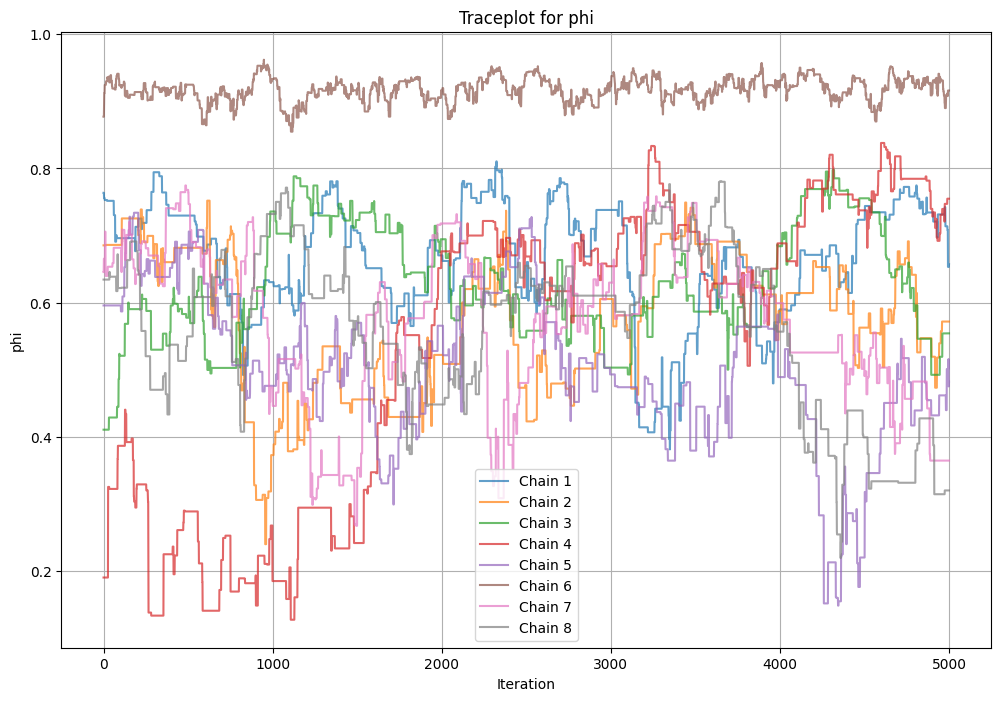

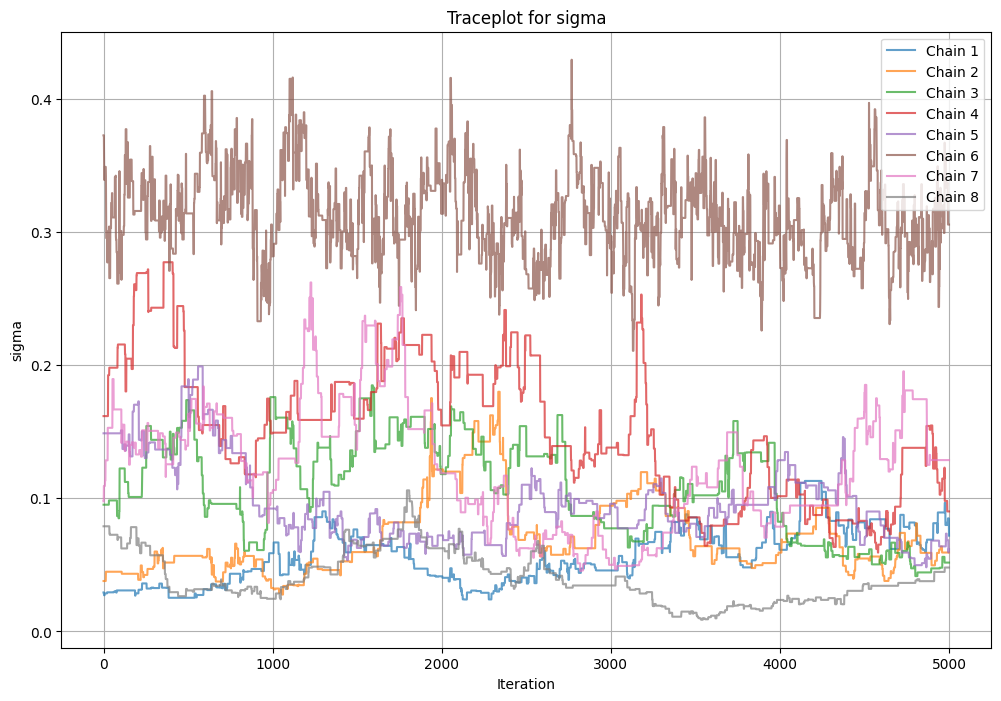

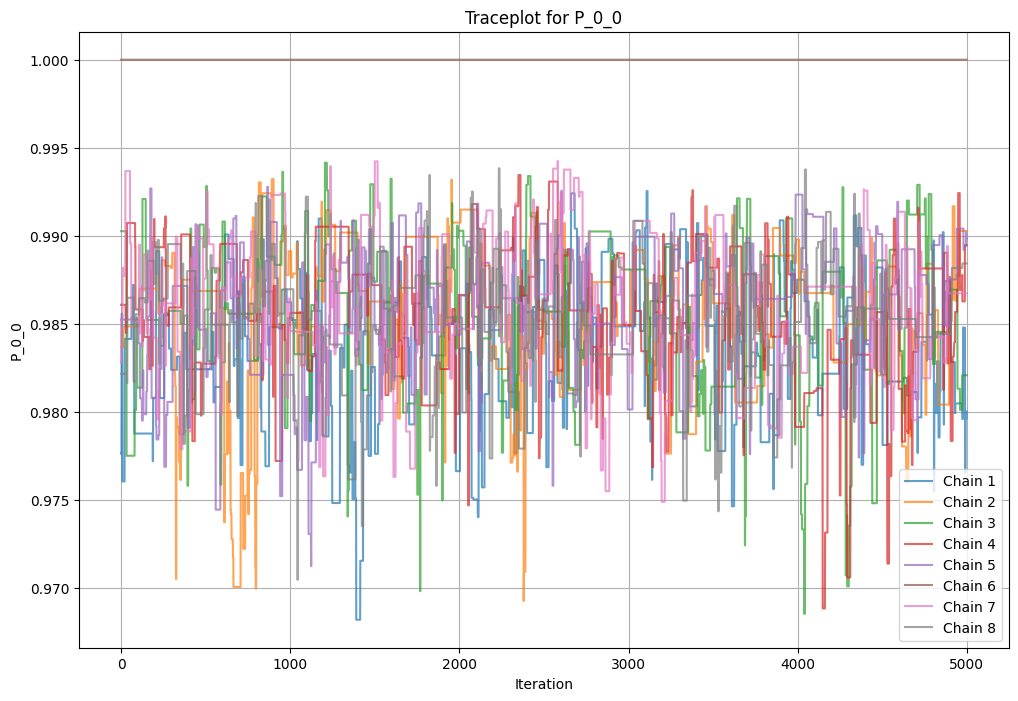

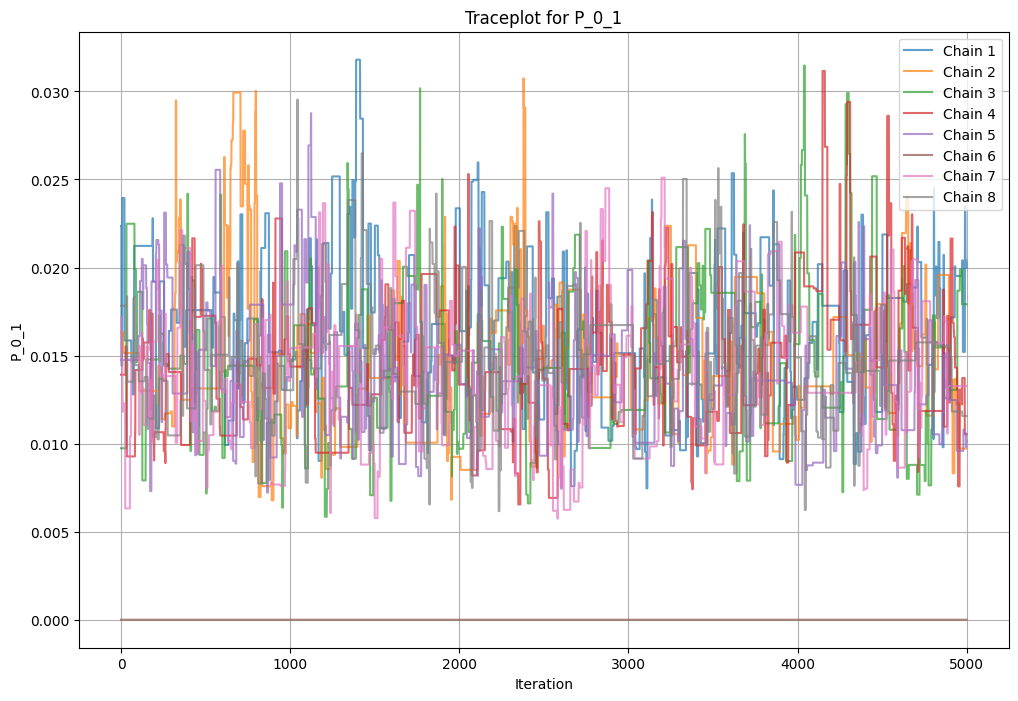

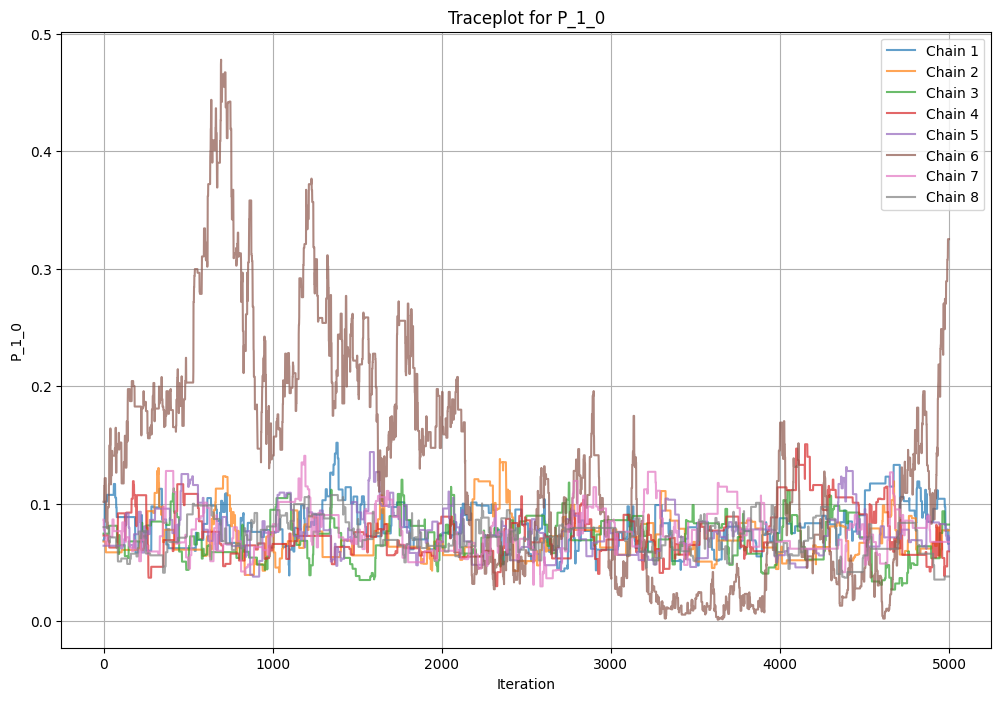

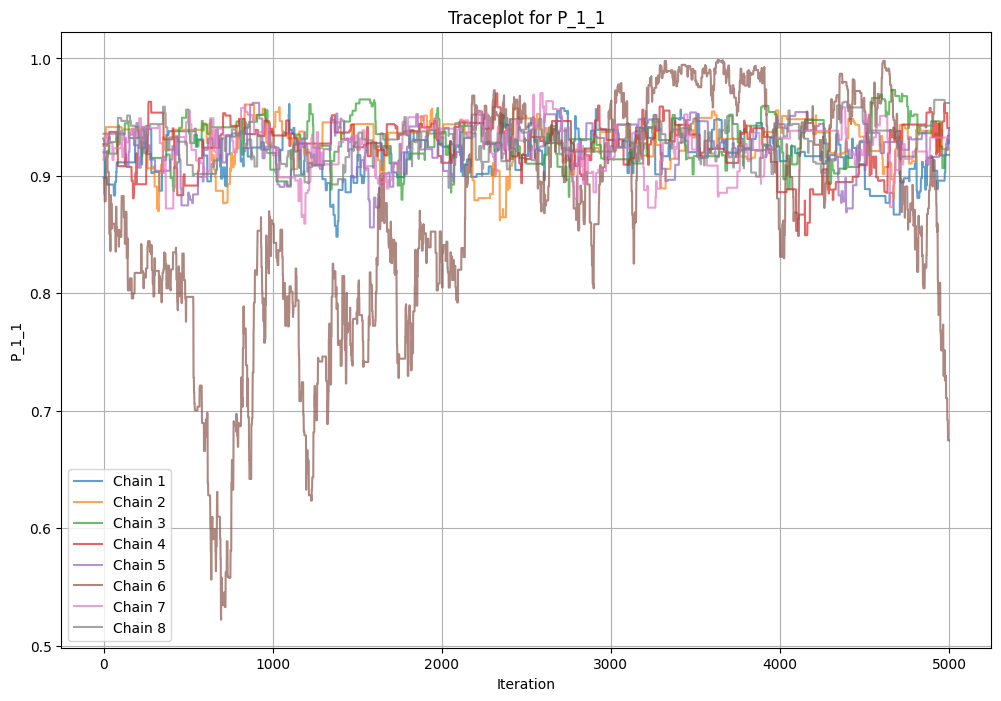

In [55]:
plt.figure(figsize=(12, 8))
for i in range(n_chains):
    plt.plot(chains_data[i]["logmarliks"], label=f"Chain {i+1}", alpha=0.7)
plt.xlabel("Iteration")
plt.ylabel("Log Marginal Likelihood")
plt.title("Log Marginal Likelihood Trace")
plt.legend()
plt.grid()
plt.savefig(results_dir / "logmarlik_trace.png")
plt.show()

for param_idx in range(n_params):
    plt.figure(figsize=(12, 8))
    for i in range(n_chains):
        plt.plot(chains_data[i]["thetas"][:, param_idx], label=f"Chain {i+1}", alpha=0.7)
    plt.xlabel("Iteration")
    plt.ylabel(parameter_names[param_idx])
    plt.title(f"Traceplot for {parameter_names[param_idx]}")
    plt.legend()
    plt.grid()
    plt.savefig(results_dir / f"{parameter_names[param_idx]}_trace.png")
    plt.show()

Now we plot the entire histogram of samples which represent the posterior distribution of $p(\theta|y_{1:T})$ for each parameter. As we have synthetic data, we can also plot the true values of parameters as vertical lines in the histogram plots. 

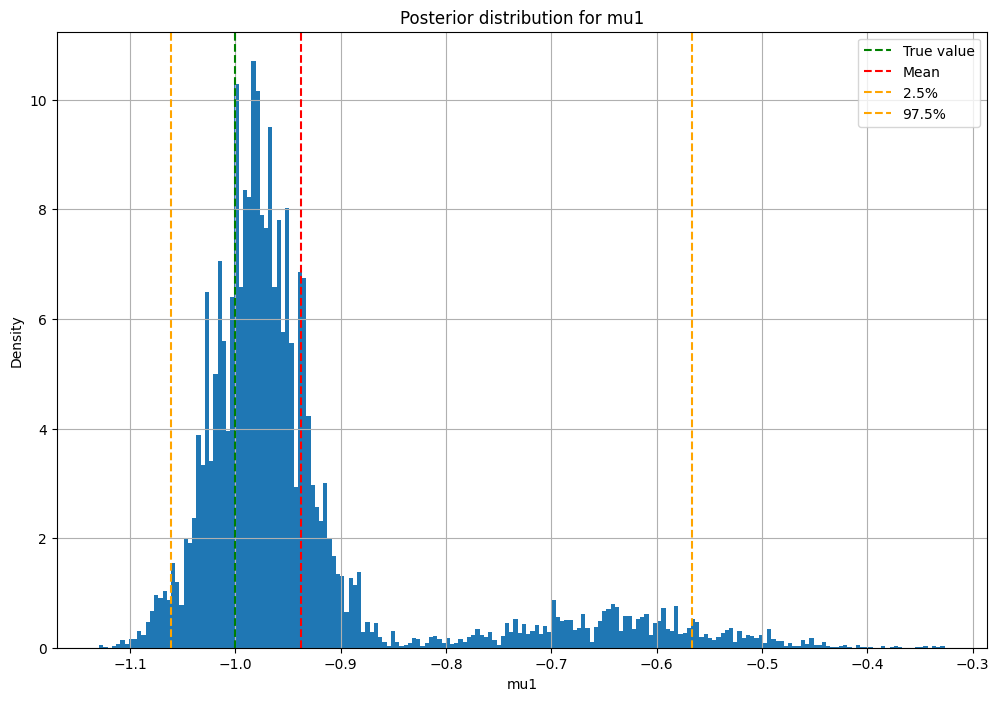

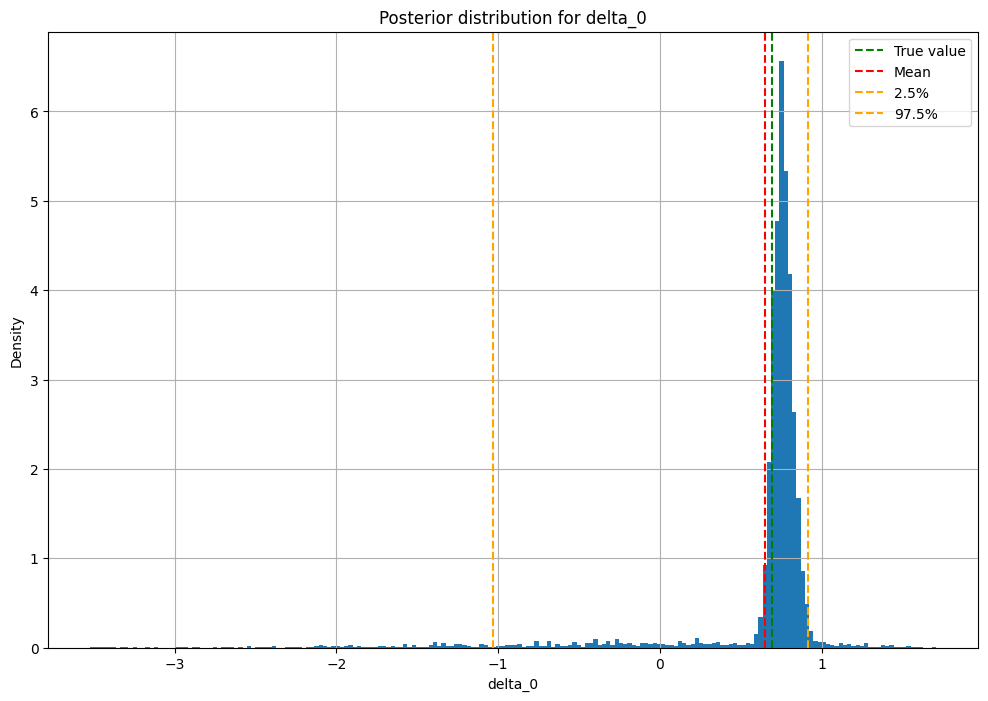

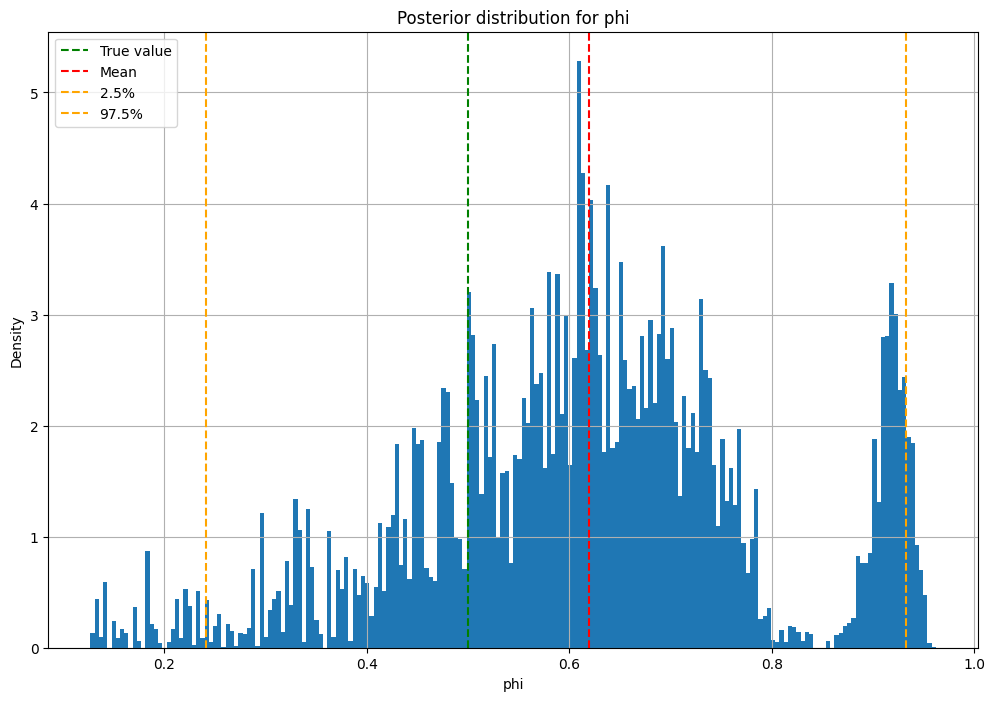

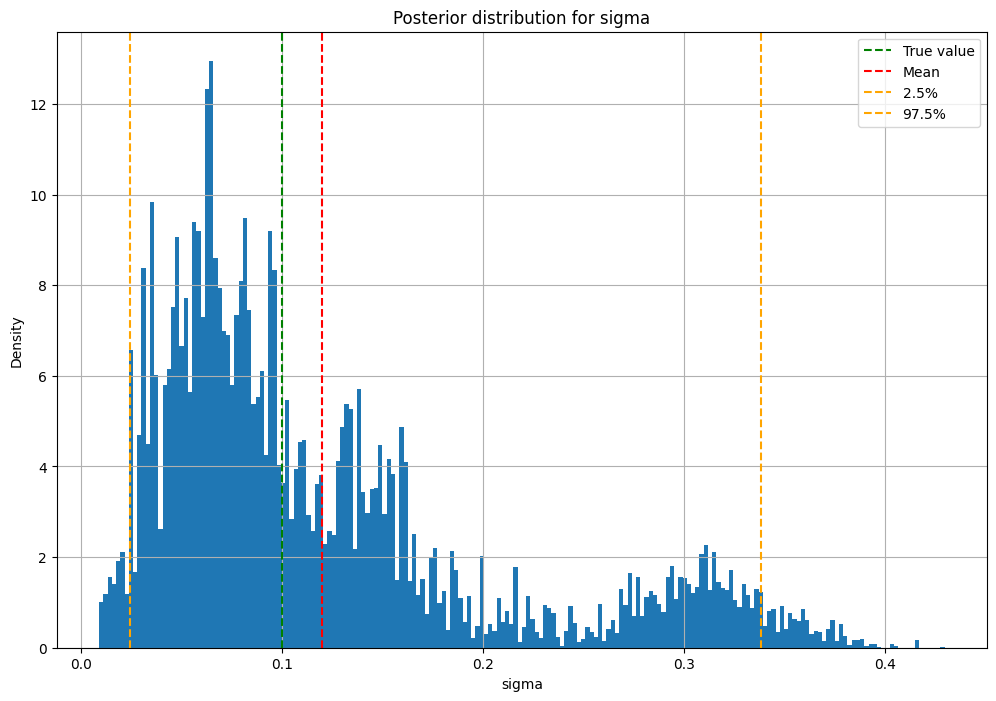

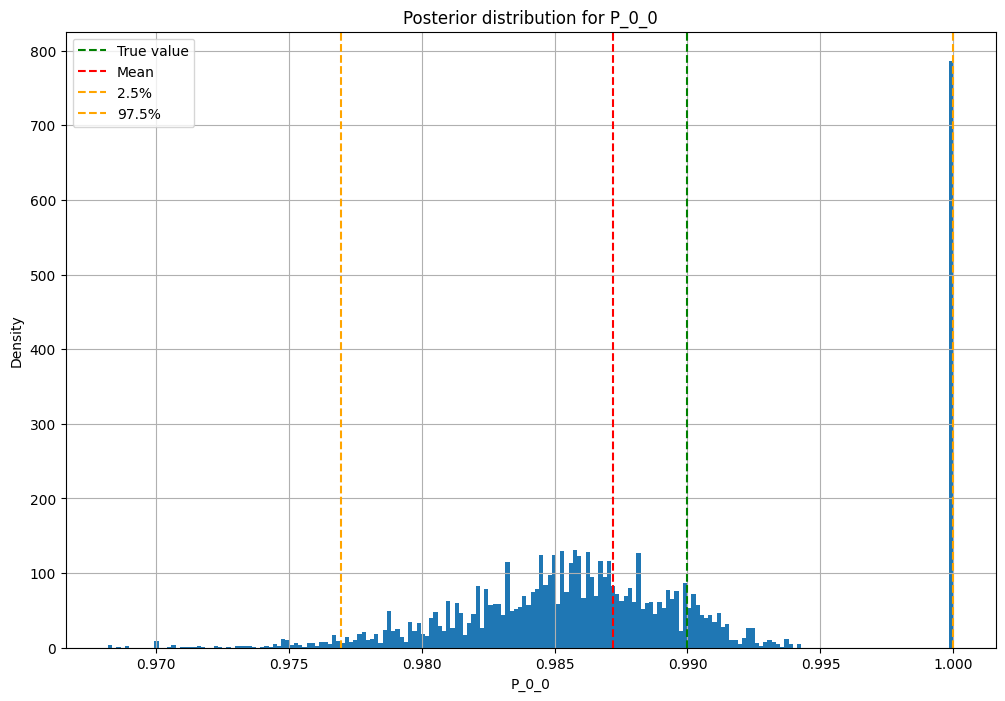

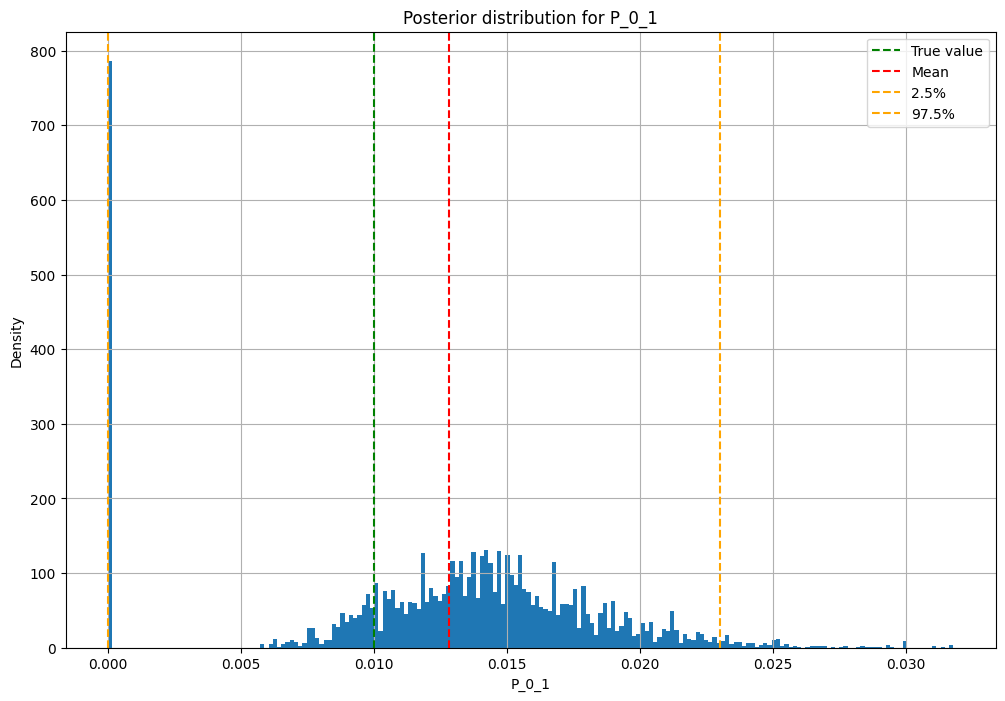

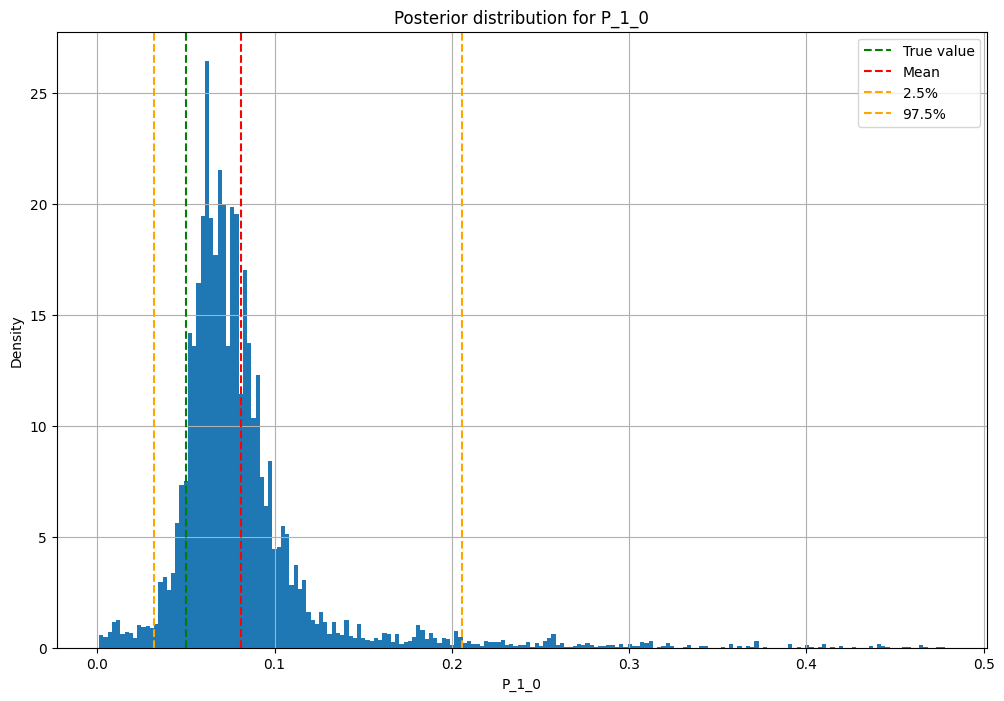

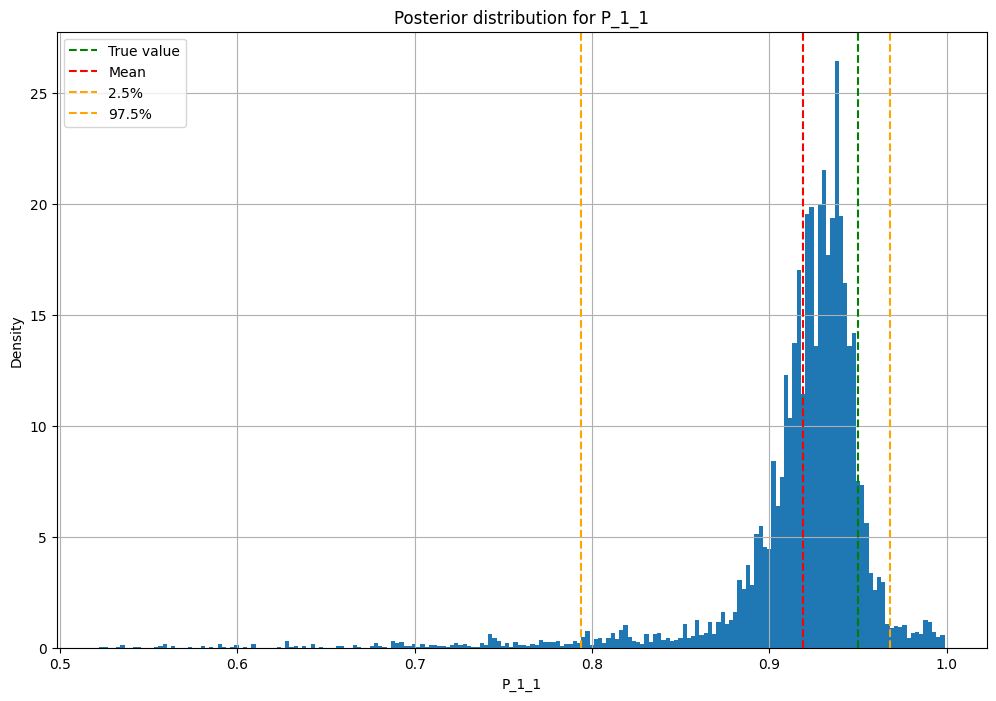

In [56]:
for param_idx in range(n_params):
    plt.figure(figsize=(12, 8))
    samples = []
    for i in range(n_chains):
        samples.extend(chains_data[i]["thetas"][:, param_idx])
    mean = np.mean(samples)
    lower, higher = np.percentile(samples, [2.5, 97.5])
    plt.hist(samples, bins=int(np.sqrt(len(samples))), density=True)
    plt.axvline(true_theta[param_idx], color='green', linestyle='--', label='True value')
    plt.axvline(mean, color='red', linestyle='--', label='Mean')
    plt.axvline(lower, color='orange', linestyle='--', label='2.5%')
    plt.axvline(higher, color='orange', linestyle='--', label='97.5%')
    plt.xlabel(parameter_names[param_idx])
    plt.ylabel("Density")
    plt.title(f"Posterior distribution for {parameter_names[param_idx]}")
    plt.grid()
    plt.legend()
    plt.savefig(results_dir / f"{parameter_names[param_idx]}_hist.png")
    plt.show()

Final thing we plot the smoothing trajectories of the latent states $h_{1:T}$ along with the true latent states.

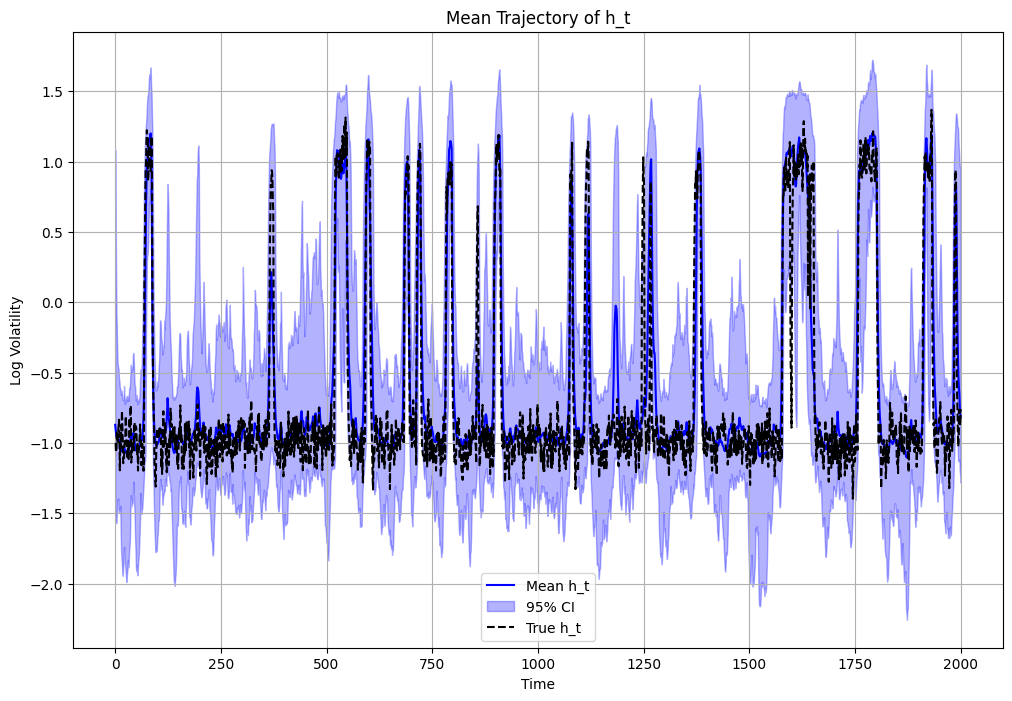

In [57]:
h_values_all_chains = []
s_values_all_chains = []
for i in range(n_chains):
    h_values = chains_data[i]["trajectories"][:, :, 0]    # shape (M, T+1)
    h_values_all_chains.append(h_values)
    # Construct back the one-hot encoded regime indicators
    s_values = chains_data[i]["trajectories"][:, :, 1:]   # shape (M, T+1, K)
    s_values_all_chains.append(s_values)

# Compute mean trajectory across all chains
h_values = np.concatenate(h_values_all_chains, axis=0)
mean_h_values = np.mean(h_values, axis=0)    # shape (T+1,)
lower, higher = np.percentile(h_values, [2.5, 97.5], axis=0)

plt.figure(figsize=(12, 8))
plt.plot(mean_h_values, label="Mean h_t", color='blue')
plt.fill_between(np.arange(len(mean_h_values)), lower, higher, color='blue', alpha=0.3, label="95% CI")
plt.plot(np.arange(1, len(h_true)+1), h_true, label="True h_t", color='black', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Log Volatility")
plt.title("Mean Trajectory of h_t")
plt.legend()
plt.grid()
plt.savefig(results_dir / "mean_h_trajectory.png")
plt.show()